### 1D code CMI simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math

Defining the code size and partitions into subregions 

In [11]:
#Total number of qubits 
N = 25 
#Size of middle region 
R = 5

#Subregion sizes
A = 5
B = 2*R 
C = N - A - B 

We calcualte CMI as:

\begin{equation}

CMI = I(A:C|B) = H(AB) + H(BC) - H(ABC) - H(B),

\end{equation}

where $H(Q)$ is the Shannon entropy of the $Q$ subregion:

\begin{equation}

H(Q) = \sum_{s} Pr(s) \cdot log_2 Pr(s), 

\end{equation}


\begin{equation}

Pr(s) = p^{|s|}(p-1)^{N-|s|},

\end{equation}

where $p$ is the noise rate (probability of a physical qubit to flip), $s \in \{0,1\}^N$ is the vector of syndormes (list of flip - entry 1, or no flip - entry 0) for each physical qubit, and N is the total number of qubits. For subregion Q, we only consider the substring (part of the vector) corresponding to qubits in Q.



Generating all possible strings of 0's and 1's of length N. We need to sum over them to calculate CMI.

In [12]:
strings = list(product([0, 1], repeat=N))

strings = np.array(strings)

print(strings)
print(strings.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
(33554432, 25)


In [36]:


def H_ABC(p,strings,N):
    """ 
    Function to compute H(ABC) for noise rate p and the list of strings
    """
    number_rows = len(strings)
    H_ABC = 0
    for s in range(number_rows):
        len_s = sum(strings[s])
        Pr = p**len_s * (1-p)**(N - len_s)
        H = -1* Pr* math.log2(Pr)
        H_ABC += H
    return H_ABC

def H_B(p,strings,stringsB,N,A,R):
    """ 
    Function to compute H(B) for noise rate p and the list of strings
    """
    number_rows = len(strings)
    number_rows_B = len(stringsB)
    H_B = 0

    for k in range(number_rows_B):
        Pr = 0
        current_string_B = stringsB[k]

        for s in range(number_rows):
            #considering subregion of the string
            new_string = np.hstack((strings[s,A:A+R],strings[s,N-R:N]))
            len_s = sum(strings[s])
            if np.array_equal(new_string, current_string_B):
                #Probability of a subregion is a marginal (sum)
                Pr += p**len_s * (1-p)**(N - len_s)

        H = -1* Pr* math.log2(Pr)
        H_B += H

    return H_B

def H_AB(p,strings,stringsAB,N,A,R):
    """ 
    Function to compute H(AB) for noise rate p and the list of strings
    """
    number_rows = len(strings)
    number_rows_AB = len(stringsAB)
    H_AB = 0

    for k in range(number_rows_AB):
        Pr = 0
        current_string_AB = stringsAB[k]

        for s in range(number_rows):
            #considering subregion of the string
            new_string = np.hstack((strings[s,0:A+R],strings[s,N-R:N]))
            len_s = sum(strings[s])
            #Probability of a subregion is a marginal (sum)
            if np.array_equal(new_string, current_string_AB):
                Pr += p**len_s * (1-p)**(N - len_s)

        H = -1* Pr* math.log2(Pr)
        H_AB += H

    return H_AB

def H_BC(p,strings,stringsBC,N,A):
    """ 
    Function to compute H(BC) for noise rate p and the list of strings
    """

    number_rows = len(strings)
    number_rows_BC = len(stringsBC)
    H_BC = 0

    for k in range(number_rows_BC):
        Pr = 0
        current_string_BC = stringsBC[k]

        for s in range(number_rows):
            #considering subregion of the string
            new_string = strings[s,A:N]
            len_s = sum(strings[s])
            #Probability of a subregion is a marginal (sum)
            if np.array_equal(new_string, current_string_BC):
                Pr += p**len_s * (1-p)**(N - len_s)

        H = -1* Pr* math.log2(Pr)
        H_BC += H

    return H_BC



Comment: the code runs for a very long time: Taking a few minutes per term

In [6]:
#Test 

s=240
print(strings[s,A:A+R])
print(strings[s,N-R:N])
new_string = np.hstack((strings[s,A:A+R],strings[s,N-R:N]))
print(new_string)

[0 0 0 0 0]
[1 0 0 0 0]
[0 0 0 0 0 1 0 0 0 0]


In [14]:
#Array of different probability values

noise_rates = np.linspace(0.01,0.99,10)
CMI = np.zeros(len(noise_rates))

for k in range(len(noise_rates)):
    p = noise_rates[k]
    cmi = H_AB(p,strings,N,A,R) + H_BC(p,strings,N,A) - H_B(p,strings,N,A,R) - H_ABC(p,strings,N)
    CMI[k] = cmi

Plot

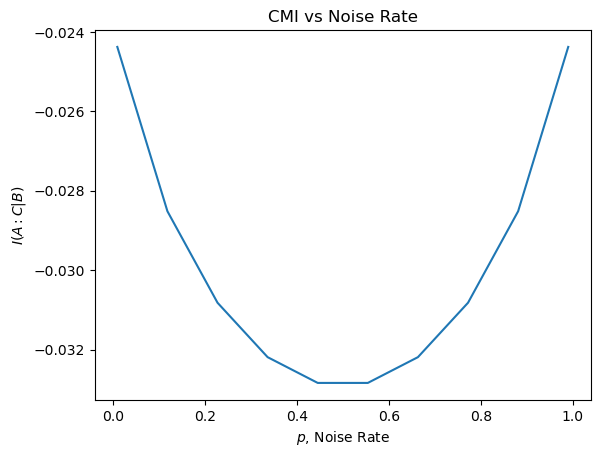

In [15]:
fig, ax = plt.subplots()

ax.plot(noise_rates , CMI)
ax.set_title("CMI vs Noise Rate")
ax.set_xlabel("$p$, Noise Rate")
ax.set_ylabel("$I(A:C|B)$")

plt.show()

Slower system but more noise rates

In [16]:
#Total number of qubits 
N1 = 12
#Size of middle region 
R1 = 2

#Subregion sizes
A1 = 4
B1 = 2*R1 
C1 = N1- A1 - B1 

Generating strings and substrings

In [ ]:
#Main string ABC

strings1 = list(product([0, 1], repeat=N1))

strings1 = np.array(strings1)

print(strings1)
print(strings1.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
(4096, 12)


In [31]:
#Substrings

stringsAB = list(product([0, 1], repeat=A1+B1))

stringsAB = np.array(stringsAB)

print(stringsAB)
print(stringsAB.shape)


stringsBC = list(product([0, 1], repeat=B1+C1))

stringsBC = np.array(stringsBC)

print(stringsBC)
print(stringsBC.shape)


stringsB = list(product([0, 1], repeat=B1))

stringsB = np.array(stringsB)

print(stringsB)
print(stringsB.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
(256, 8)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 1 0]
 ...
 [1 1 1 ... 1 0 1]
 [1 1 1 ... 1 1 0]
 [1 1 1 ... 1 1 1]]
(256, 8)
[[0 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 0 1 1]
 [0 1 0 0]
 [0 1 0 1]
 [0 1 1 0]
 [0 1 1 1]
 [1 0 0 0]
 [1 0 0 1]
 [1 0 1 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]]
(16, 4)


In [37]:
print(H_ABC(0.5,strings1,N1))

print(H_B(0.5,strings1,stringsB,N1,A1,R1))

print(H_AB(0.5,strings1,stringsAB,N1,A1,R1))

print(H_BC(0.5,strings1,stringsBC,N1,A1))

12.0
4.0
8.0
8.0


In [49]:
#Array of different probability values

noise_rates1 = np.linspace(0.0001,0.03,15)
CMI1 = np.zeros(len(noise_rates1))

for k in range(len(noise_rates1)):
    p = noise_rates1[k]
    cmi1 = H_AB(p,strings1,stringsAB,N1,A1,R1) + H_BC(p,strings1,stringsBC,N1,A1) - H_B(p,strings1,stringsB,N1,A1,R1) - H_ABC(p,strings1,N1)
    print(cmi1)
    CMI1[k] = cmi1

2.498001805406602e-16
8.1601392309949e-15
-3.375077994860476e-14
1.1102230246251565e-16
-1.1024514634527804e-13
-3.708144902248023e-14
7.460698725481052e-14
7.194245199571014e-14
-1.6653345369377348e-14
9.814371537686384e-14
7.549516567451064e-15
1.6653345369377348e-14
1.5987211554602254e-14
-9.947598300641403e-14
-1.1857181902996672e-13


In [33]:
print(H_ABC(0.9,strings1,N1))

0.004303698028093586


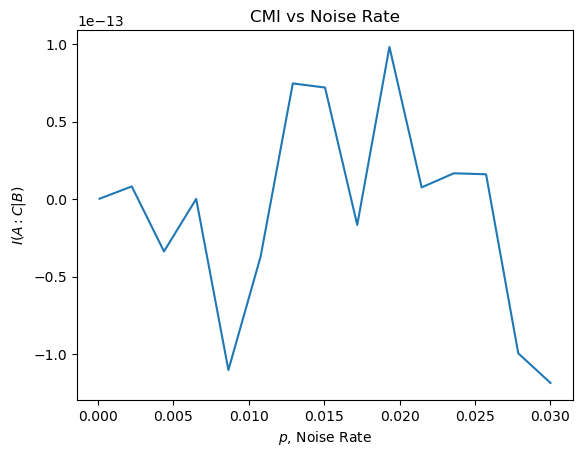

In [50]:
fig, ax = plt.subplots()

ax.plot(noise_rates1 , CMI1)
#ax.plot(noise_rates , CMI)
ax.set_title("CMI vs Noise Rate")
ax.set_xlabel("$p$, Noise Rate")
ax.set_ylabel("$I(A:C|B)$")

plt.show()

In [51]:
#Total number of qubits 
N2 = 18
#Size of middle region 
R2 = 3

#Subregion sizes
A2 = 6
B2 = 2*R2 
C2 = N2- A2 - B2 

#Full string
strings2 = list(product([0, 1], repeat=N2))

strings2 = np.array(strings2)

#Substrings

stringsAB2 = list(product([0, 1], repeat=A2+B2))

stringsAB2 = np.array(stringsAB2)



stringsBC2 = list(product([0, 1], repeat=B2+C2))

stringsBC2 = np.array(stringsBC2)



stringsB2 = list(product([0, 1], repeat=B2))

stringsB2 = np.array(stringsB2)


noise_rates1 = np.linspace(0.0001,0.03,15)
CMI2 = np.zeros(len(noise_rates1))

for k in range(len(noise_rates1)):
    p = noise_rates1[k]
    cmi2 = H_AB(p,strings2,stringsAB2,N2,A2,R2) + H_BC(p,strings2,stringsBC2,N2,A2) - H_B(p,strings2,stringsB2,N2,A2,R2) - H_ABC(p,strings2,N2)
    print(cmi2)
    CMI2[k] = cmi2


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots()

ax.plot(noise_rates1 , CMI1)
ax.plot(noise_rates1 , CMI2)
#ax.plot(noise_rates , CMI)
ax.set_title("CMI vs Noise Rate")
ax.set_xlabel("$p$, Noise Rate")
ax.set_ylabel("$I(A:C|B)$")

plt.show()

In [52]:
p = 0.02
cmi2 = H_AB(p,strings2,stringsAB2,N2,A2,R2) + H_BC(p,strings2,stringsBC2,N2,A2) - H_B(p,strings2,stringsB2,N2,A2,R2) - H_ABC(p,strings2,N2)
print(cmi2)

KeyboardInterrupt: 

In [55]:
H_AB(p,strings2,stringsAB2,N2,A2,R2)

KeyboardInterrupt: 

In [54]:
H_ABC(p,strings2,N2)

np.float64(2.5459297657379425)